# **Exploratory Data Analysis (EDA)**

## **Load & keep only English tweets**

### Imports (for all EDA blocks)

In [ ]:
# Base
import pandas as pd
import numpy as np
import re
import random

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

# Statistics
from scipy.stats import mannwhitneyu

# Machine Learning utils
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 200)

# Random seed for reproducibility
np.random.seed(42)
random.seed(42)


In [ ]:
# โหลด dataset
DATA_PATH = "twitter_human_bots_dataset.csv"
df = pd.read_csv(DATA_PATH)

# กรองเฉพาะภาษาอังกฤษ
df = df[df["lang"] == "en"].copy()
print("After filtering (lang == 'en'):", df.shape)

df.head(3)

After filtering (lang == 'en'): (21450, 20)


,Unnamed: 0,created_at,default_profile,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,id,lang,location,profile_background_image_url,profile_image_url,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,2016-10-15 21:32:11,False,False,"Blame @xaiax, Inspired by @MakingInvisible, using cmu phonetic data to produce incongruous matches.\nSome images via Lorem Flickr.",4,1589,4,False,787405734442958848,en,unknown,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/787412182602428416/5WawZkPa_normal.jpg,best_in_dumbest,11041,False,7.870,1403,bot
1,1,2016-11-09 05:01:30,False,False,"Photographing the American West since 1980. I specialize in location portraits & events, both indoors & outside, using natural light & portable studio lighting.",536,860,880,False,796216118331310080,en,Estados Unidos,http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/802329632838037504/CQN6gP7k_normal.jpg,CJRubinPhoto,252,False,0.183,1379,human
2,2,2017-06-17 05:34:27,False,False,Scruffy looking nerf herder and @twitch broadcaster\n\nContact 📬 svgegent@gmail.com,3307,172,594,True,875949740503859204,en,"Los Angeles, CA",http://abs.twimg.com/images/themes/theme1/bg.png,http://pbs.twimg.com/profile_images/1278890453291565057/8doB1itg_normal.jpg,SVGEGENT,1001,False,0.864,1159,human


## **Overview & Schema**

In [ ]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nInfo:")
print(df.dtypes.to_string())

Shape: (21450, 20)
Columns: ['Unnamed: 0', 'created_at', 'default_profile', 'default_profile_image', 'description', 'favourites_count', 'followers_count', 'friends_count', 'geo_enabled', 'id', 'lang', 'location', 'profile_background_image_url', 'profile_image_url', 'screen_name', 'statuses_count', 'verified', 'average_tweets_per_day', 'account_age_days', 'account_type']

Info:
Unnamed: 0                        int64
created_at                       object
default_profile                    bool
default_profile_image              bool
description                      object
favourites_count                  int64
followers_count                   int64
friends_count                     int64
geo_enabled                        bool
id                                int64
lang                             object
location                         object
profile_background_image_url     object
profile_image_url                object
screen_name                      object
statuses_count      

In [ ]:
# เปลี่ยนชื่อ attribute เพื่อความไม่กำกวม
df = df.rename(columns={"default_profile": "default_background_image"})
print(df.columns)

Index(['Unnamed: 0', 'created_at', 'default_background_image',
       'default_profile_image', 'description', 'favourites_count',
       'followers_count', 'friends_count', 'geo_enabled', 'id', 'lang',
       'location', 'profile_background_image_url', 'profile_image_url',
       'screen_name', 'statuses_count', 'verified', 'average_tweets_per_day',
       'account_age_days', 'account_type'],
      dtype='object')


In [ ]:
def schema_summary(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for col in df.columns:
        s = df[col]
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "missing": int(s.isna().sum()),
            "missing_%": round(s.isna().mean()*100, 2),
            "unique": int(s.nunique(dropna=True)),
            "example": s.dropna().iloc[0] if s.notna().any() else None
        })
    return pd.DataFrame(rows).sort_values(["missing_%","column"]).reset_index(drop=True)

schema_df = schema_summary(df)
schema_df

,column,dtype,non_null,missing,missing_%,unique,example
0,Unnamed: 0,int64,21450,0,0.00,21450,0
1,account_age_days,int64,21450,0,0.00,4008,1403
2,account_type,object,21450,0,0.00,2,bot
3,average_tweets_per_day,float64,21450,0,0.00,9737,7.87
4,created_at,object,21450,0,0.00,21449,2016-10-15 21:32:11
5,default_background_image,bool,21450,0,0.00,2,False
6,default_profile_image,bool,21450,0,0.00,2,False
7,description,object,21450,0,0.00,21353,"Blame @xaiax, Inspired by @MakingInvisible, using cmu phonetic data to produce incongruous matches.\nSome images via Lorem Flickr."
8,favourites_count,int64,21450,0,0.00,11505,4
9,followers_count,int64,21450,0,0.00,9398,1589


In [ ]:
missing_cols = schema_df[schema_df["missing"] > 0].sort_values("missing_%", ascending=False)
if missing_cols.empty:
    print("ไม่มีคอลัมน์ที่ missing")
else:
    print("Columns with missing values:")
    display(missing_cols[["column", "missing", "missing_%", "unique"]])


Columns with missing values:


,column,missing,missing_%,unique
19,profile_background_image_url,2443,11.39,20
18,location,2,0.01,7892
14,profile_image_url,1,0.00,21417


In [ ]:
# ตัดคอลัมน์ที่ไม่ได้ใช้งานออก
df = df.drop(columns=["id","profile_image_url","profile_background_image_url","location"])
print("Shape:", df.shape)

Shape: (21450, 16)


## **Target & Class Balance**

Target distribution (count):
account_type
human    16212
bot       5238
Name: count, dtype: int64

Target distribution (%):
account_type
human    75.58 %
bot      24.42 %
Name: proportion, dtype: object

Class ratio (max:min) ≈ 3.1:1


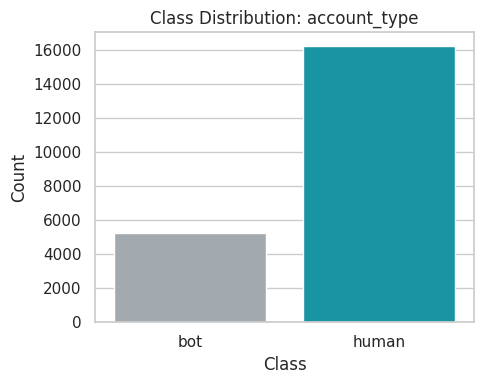

In [ ]:
# 1) ตั้งชื่อคอลัมน์เป้าหมาย
TARGET_COL = "account_type"   # binary classification: bot / human

# 2) นับจำนวนแต่ละคลาส
vc = df[TARGET_COL].value_counts(dropna=False)
vcn = df[TARGET_COL].value_counts(normalize=True, dropna=False).round(4) * 100

print("Target distribution (count):")
print(vc)
print("\nTarget distribution (%):")
print(vcn.astype(str) + " %")

# 3) คำนวณอัตราส่วนคลาส (imbalance ratio)
if len(vc) >= 2:
    maj, minc = int(vc.max()), int(vc.min())
    ratio = np.inf if minc == 0 else round(maj / minc, 2)
    print(f"\nClass ratio (max:min) ≈ {ratio}:1")

# 4) แสดงกราฟ class balance
plt.figure(figsize=(5,4))
sns.countplot(data=df, x=TARGET_COL, hue=TARGET_COL, palette={"bot": "#A0ABB1", "human": "#01A6BA"}, legend=False, )
plt.title(f"Class Distribution: {TARGET_COL}")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## **Numeric EDA + Descriptive Stats**

In [ ]:
# กำหนดคอลัมน์เชิงตัวเลข
num_cols = [
    'favourites_count','followers_count','friends_count',
    'statuses_count','average_tweets_per_day','account_age_days'
]

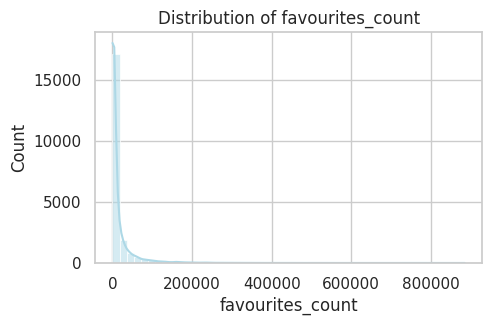

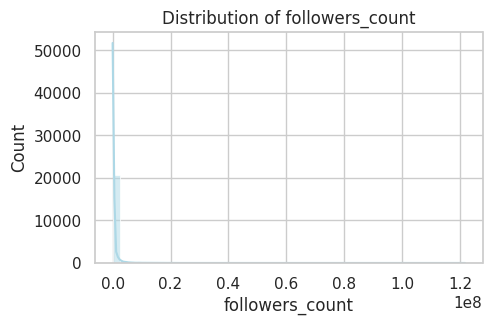

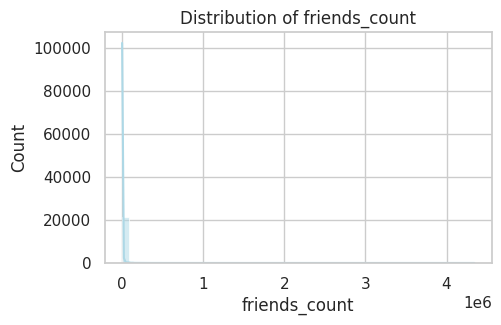

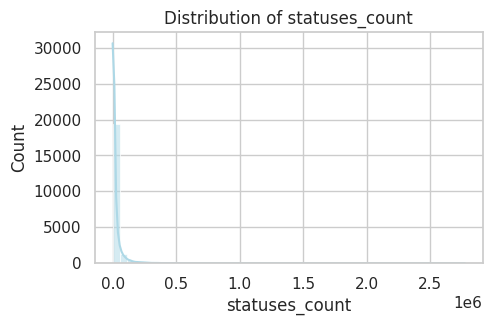

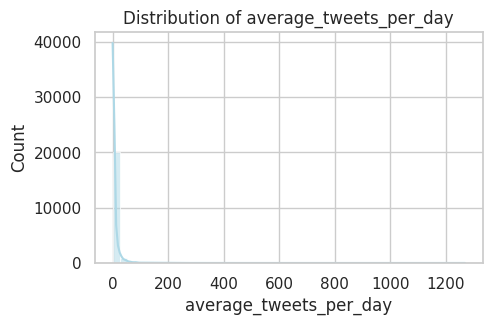

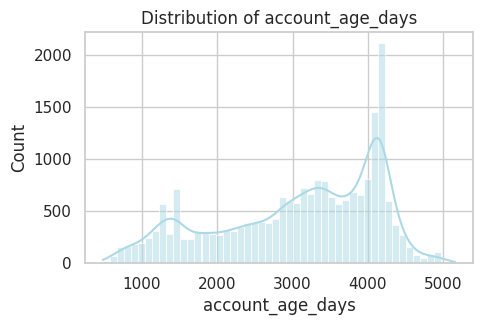

In [ ]:
for c in num_cols:
    plt.figure(figsize=(5, 3))
    sns.histplot(df[c], bins=50, kde=True, color="lightblue")
    plt.title(f"Distribution of {c}")
    plt.show()

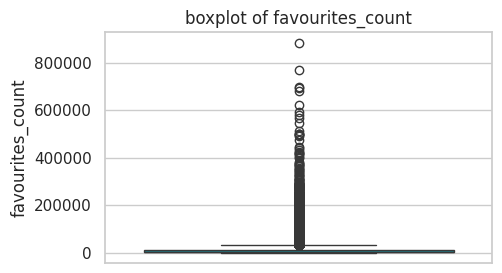

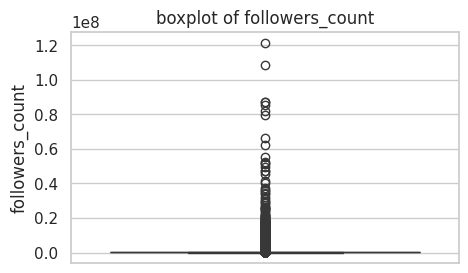

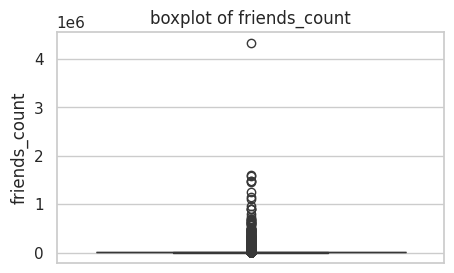

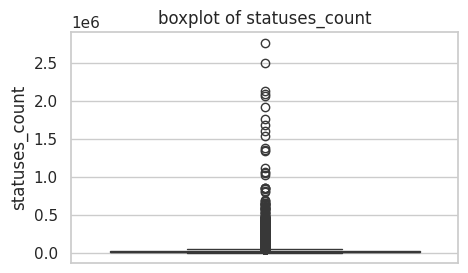

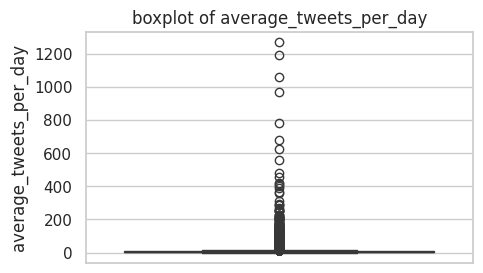

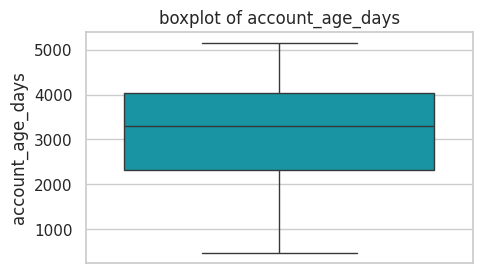

In [ ]:
for c in num_cols:
    plt.figure(figsize=(5, 3))
    sns.boxplot(df[c], color="#01A6BA")
    plt.title(f"boxplot of {c}")
    plt.show()

,feature,p_MW_log,cohens_d_log
2,friends_count,0.000000e+00,-1.175506
1,followers_count,0.000000e+00,-1.008091
0,favourites_count,0.000000e+00,-0.900342
3,statuses_count,0.000000e+00,-0.742151
5,account_age_days,0.000000e+00,-0.584826
4,average_tweets_per_day,3.541321e-270,-0.409027


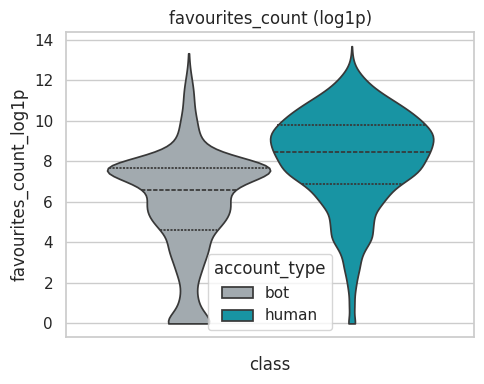

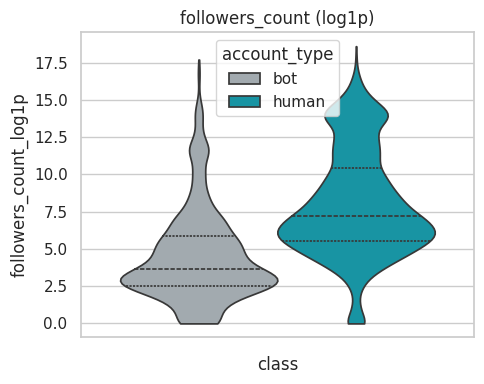

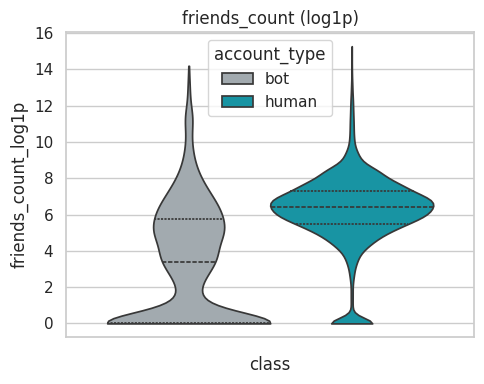

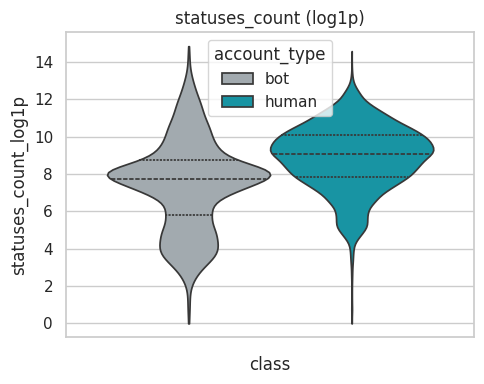

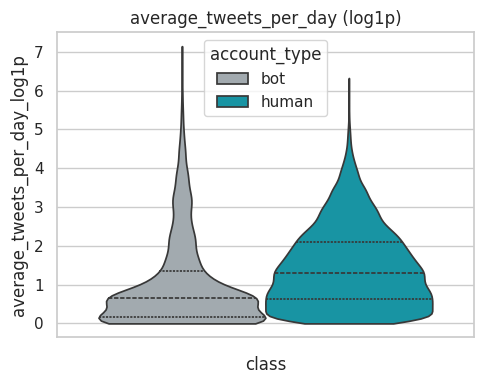

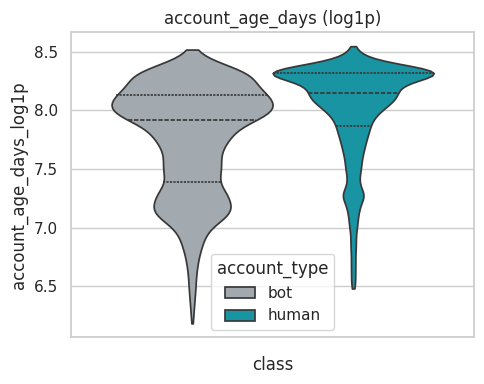

In [ ]:
# helper: Cohen's d (ขนาดอิทธิพล)
def cohens_d(a, b):
    a = pd.Series(a).dropna(); b = pd.Series(b).dropna()
    na, nb = len(a), len(b)
    if na < 2 or nb < 2: return np.nan
    va, vb = a.var(ddof=1), b.var(ddof=1)
    pooled = ((na-1)*va + (nb-1)*vb) / (na+nb-2)
    return (a.mean() - b.mean()) / np.sqrt(pooled) if pooled > 0 else np.nan

# คำนวณสถิติแยกคลาสบน log1p
rows = []
bmask = df[TARGET_COL] == "bot"
hmask = df[TARGET_COL] == "human"

for c in num_cols:
    log_b = np.log1p(df.loc[bmask, c])
    log_h = np.log1p(df.loc[hmask, c])
    p = mannwhitneyu(log_b, log_h, alternative="two-sided").pvalue
    d = cohens_d(log_b, log_h)
    rows.append({"feature": c, "p_MW_log": p, "cohens_d_log": d})

num_stats_en = pd.DataFrame(rows).sort_values("cohens_d_log")
display(num_stats_en)

# plot violin plot ของ log1p
for c in num_cols:
    fig, ax = plt.subplots(figsize=(5, 4))

    df_tmp = df.copy()
    df_tmp[c + "_log1p"] = np.log1p(df_tmp[c])
    sns.violinplot(
        data=df_tmp, hue=TARGET_COL, y=c + "_log1p",
        ax=ax, cut=0, inner="quartile",
        palette = {"bot": "#A0ABB1", "human": "#01A6BA"}
    )
    ax.set_title(f"{c} (log1p)")
    ax.set_xlabel("class")
    ax.set_ylabel(c + "_log1p")

    plt.tight_layout()
    plt.show()



### Descriptive Stats by Class (bot vs human)

In [ ]:
classes = ["bot", "human"]  # สั่งลำดับคอลัมน์ให้คงที่

# เตรียมเวอร์ชัน log1p
df_stats = df.copy()
for c in num_cols:
    df_stats[c + "_log1p"] = np.log1p(df_stats[c])

def class_stats_wide(df_in: pd.DataFrame, cols: list, target: str, classes_order: list):
    rows = []
    for c in cols:
        row = {"feature": c}
        for cls in classes_order:
            s = df_in.loc[df_in[target] == cls, c].dropna()
            if len(s) == 0:
                # เผื่อกรณีไม่มีคลาสนั้นใน subset
                vals = {"count": 0, "mean": np.nan, "median": np.nan, "std": np.nan,
                        "min": np.nan, "q1": np.nan, "q3": np.nan, "max": np.nan, "iqr": np.nan}
            else:
                q1 = s.quantile(0.25); q3 = s.quantile(0.75)
                vals = {
                    "count": int(s.count()),
                    "mean":  float(s.mean()),
                    "median":float(s.median()),
                    "std":   float(s.std(ddof=1)),
                    "min":   float(s.min()),
                    "q1":    float(q1),
                    "q3":    float(q3),
                    "max":   float(s.max()),
                    "iqr":   float(q3 - q1),
                }
            # เติมเป็นคอลัมน์แบบ <class>_<metric>
            for k, v in vals.items():
                row[f"{cls}_{k}"] = v
        rows.append(row)
    out = pd.DataFrame(rows).set_index("feature")
    # จัดลำดับคอลัมน์ให้อ่านง่าย: bot_*, human_*
    ordered_cols = [f"{cls}_{m}" for cls in classes_order for m in ["count","mean","median","std","min","q1","q3","max","iqr"]]
    existing = [c for c in ordered_cols if c in out.columns]
    out = out[existing]
    return out

# สถิติบน "ค่าดิบ"
desc_raw = class_stats_wide(df_stats, num_cols, TARGET_COL, classes)
display(desc_raw.round(3))

# สถิติบน "log1p"
log_cols = [c + "_log1p" for c in num_cols]
desc_log = class_stats_wide(df_stats, log_cols, TARGET_COL, classes)
desc_log.index = [i.replace("_log1p","") for i in desc_log.index]
display(desc_log.round(3))

,bot_count,bot_mean,bot_median,bot_std,bot_min,bot_q1,bot_q3,bot_max,bot_iqr,human_count,human_mean,human_median,human_std,human_min,human_q1,human_q3,human_max,human_iqr
feature,,,,,,,,,,,,,,,,,,
favourites_count,5238,5329.910,744.000,26458.898,0.0,99.000,2208.750,6.225110e+05,2109.75,16212,18609.595,4738.000,40811.820,0.0,984.750,17746.500,8.851230e+05,16761.750
followers_count,5238,117082.944,38.000,1546838.208,0.0,11.000,357.750,4.955794e+07,346.75,16212,466585.215,1383.000,2869302.539,0.0,254.000,33679.000,1.216415e+08,33425.000
friends_count,5238,5435.754,28.000,50723.438,0.0,0.000,310.000,1.473166e+06,310.00,16212,4447.567,606.000,50297.638,0.0,237.000,1462.250,4.343060e+06,1225.250
statuses_count,5238,22442.001,2275.000,107811.669,0.0,325.500,6391.500,2.771910e+06,6066.00,16212,23086.681,8471.000,49938.589,0.0,2496.750,23894.000,2.129049e+06,21397.250
average_tweets_per_day,5238,8.431,0.907,43.312,0.0,0.184,2.834,1.269055e+03,2.65,16212,7.131,2.638,15.276,0.0,0.854,7.258,5.579270e+02,6.403
account_age_days,5238,2587.767,2747.000,1032.661,483.0,1620.000,3386.750,5.011000e+03,1766.75,16212,3232.908,3471.000,1012.829,651.0,2599.000,4092.000,5.158000e+03,1493.000


,bot_count,bot_mean,bot_median,bot_std,bot_min,bot_q1,bot_q3,bot_max,bot_iqr,human_count,human_mean,human_median,human_std,human_min,human_q1,human_q3,human_max,human_iqr
favourites_count,5238,5.929,6.613,2.706,0.000,4.605,7.701,13.342,3.095,16212,8.121,8.464,2.339,0.00,6.893,9.784,13.693,2.891
followers_count,5238,4.518,3.664,3.126,0.000,2.485,5.883,17.719,3.398,16212,8.035,7.233,3.598,0.00,5.541,10.425,18.617,4.883
friends_count,5238,3.343,3.367,3.173,0.000,0.000,5.740,14.203,5.740,16212,6.160,6.409,2.084,0.00,5.472,7.288,15.284,1.816
statuses_count,5238,7.426,7.730,2.411,0.000,5.788,8.763,14.835,2.974,16212,8.861,9.045,1.751,0.00,7.823,10.081,14.571,2.258
average_tweets_per_day,5238,1.019,0.645,1.158,0.000,0.169,1.344,7.147,1.175,16212,1.452,1.291,1.024,0.00,0.618,2.111,6.326,1.494
account_age_days,5238,7.762,7.919,0.469,6.182,7.391,8.128,8.520,0.737,16212,8.012,8.152,0.413,6.48,7.863,8.317,8.548,0.454


## **Boolean EDA (by class)**

,feature,P(True|bot),P(True|human),odds_ratio(True: bot vs human)
0,default_background_image,0.567010,0.277510,3.409303
2,geo_enabled,0.213249,0.591105,0.187498
3,verified,0.032837,0.313472,0.074357
1,default_profile_image,0.003246,0.000987,3.295968


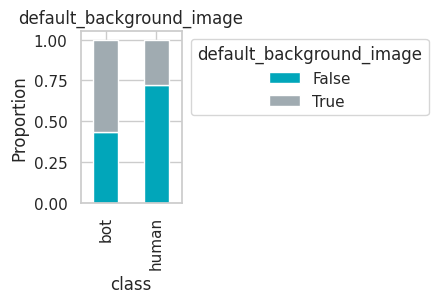

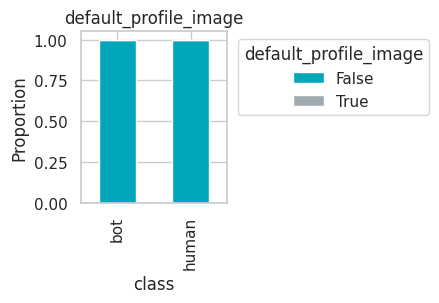

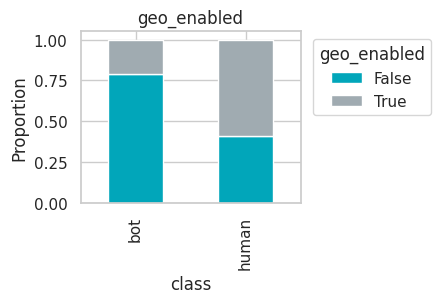

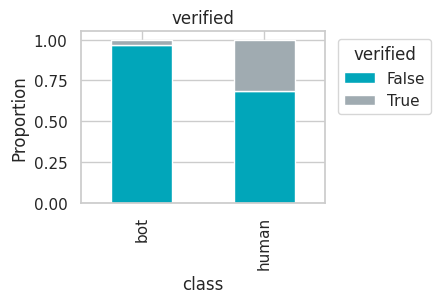

In [ ]:
bool_cols = ['default_background_image','default_profile_image','geo_enabled','verified']
bool_cols = [c for c in bool_cols if c in df.columns]

summary = []
for c in bool_cols:
    # สัดส่วนในแต่ละคลาส (คอลัมน์รวม = 1)
    ct = pd.crosstab(df[c], df[TARGET_COL], normalize="columns")

    # คำนวณ odds ratio สำหรับค่า True ระหว่าง bot vs human
    a = int((df[c] & (df[TARGET_COL]=="bot")).sum())
    b = int(((~df[c]) & (df[TARGET_COL]=="bot")).sum())
    c_ = int((df[c] & (df[TARGET_COL]=="human")).sum())
    d = int(((~df[c]) & (df[TARGET_COL]=="human")).sum())
    odds = (a/b) / (c_/d) if min(a,b,c_,d) > 0 else float('nan')

    summary.append({
        "feature": c,
        "P(True|bot)": float(ct.loc[True,"bot"]) if True in ct.index else 0.0,
        "P(True|human)": float(ct.loc[True,"human"]) if True in ct.index else 0.0,
        "odds_ratio(True: bot vs human)": odds
    })

bool_stats = pd.DataFrame(summary).sort_values("P(True|bot)", ascending=False)
display(bool_stats)

# กราฟสัดส่วนแบบ stacked (อ่านง่าย ไม่ชน warning ของ seaborn)
for c in bool_cols:
    plt.figure(figsize=(4.5,3.2))
    tab = pd.crosstab(df[TARGET_COL], df[c], normalize="index")
    tab.plot(kind="bar", stacked=True, ax=plt.gca(), legend=True, color=["#01A6BA","#A0ABB1"])
    plt.title(c)
    plt.ylabel("Proportion")
    plt.xlabel("class")
    plt.legend(title=c, bbox_to_anchor=(1.02,1), loc="upper left")
    plt.tight_layout()
    plt.show()


## **Text EDA (description)**

,bot_mean,human_mean,bot_median,human_median
desc_len,81.960,98.100,72.0,103.0
desc_words,12.665,14.570,11.0,15.0
desc_urls,0.267,0.115,0.0,0.0
desc_hashtags,0.253,0.520,0.0,0.0
desc_mentions,0.223,0.509,0.0,0.0


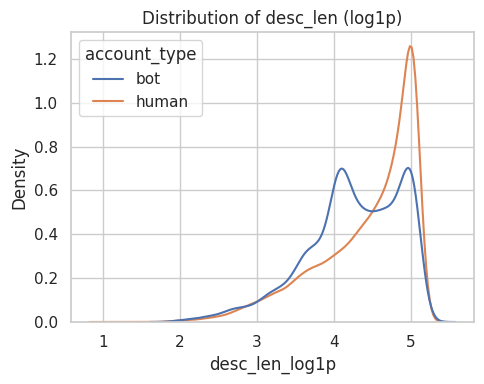

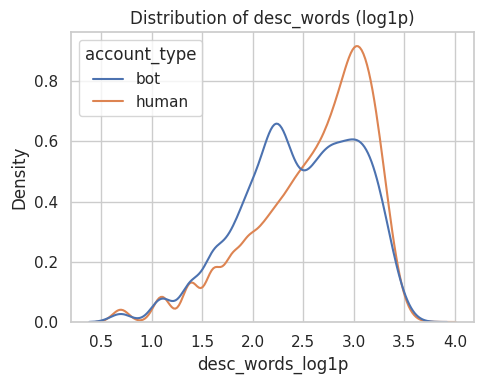

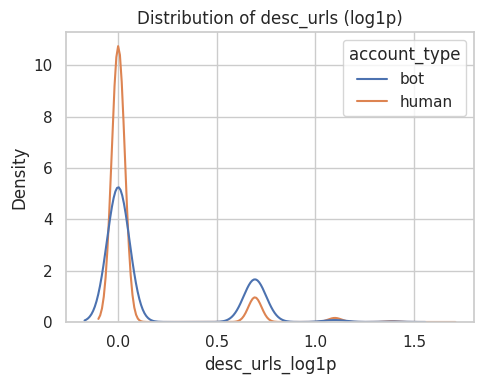

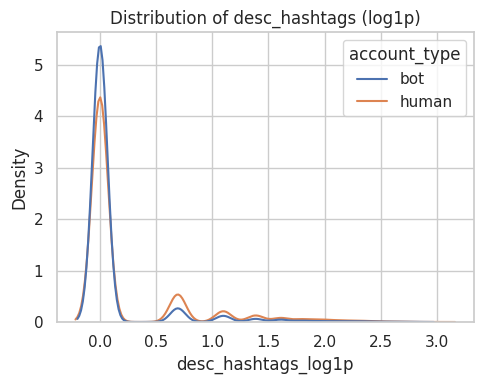

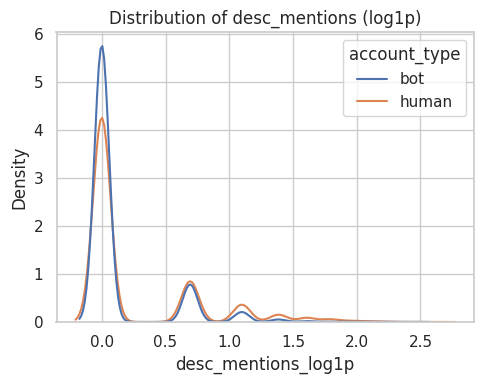

Top terms in BOT:


,term,avg_tfidf
0,https,0.067376
1,come,0.045489
2,like,0.025536
3,love,0.020319
4,check,0.019600
5,bot,0.017066
6,trading,0.015032
7,lover,0.014935
8,waiting,0.014857
9,life,0.013787


Top terms in HUMAN:


,term,avg_tfidf
0,https,0.023039
1,love,0.013223
2,com,0.011253
3,life,0.011083
4,writer,0.010901
5,twitter,0.010321
6,instagram,0.009423
7,official,0.009417
8,author,0.008887
9,music,0.008682


In [ ]:
# 1) ฟีเจอร์พื้นฐานจากข้อความ
def text_stats(s: pd.Series) -> pd.DataFrame:
    s = s.fillna("")
    urls     = s.str.count(r"http[s]?://\S+")
    hashtags = s.str.count(r"#\w+")
    mentions = s.str.count(r"@\w+")
    lengths  = s.str.len()
    words    = s.str.split().map(len)
    return pd.DataFrame({
        "desc_len": lengths,
        "desc_words": words,
        "desc_urls": urls,
        "desc_hashtags": hashtags,
        "desc_mentions": mentions
    })

txt_df = text_stats(df["description"])
txt_df[TARGET_COL] = df[TARGET_COL].values

# 2) สถิติแยกคลาส
def by_class_stats(col):
    g = txt_df.groupby(TARGET_COL)[col]
    return pd.DataFrame({
        "bot_mean":   [g.mean().get("bot", np.nan)],
        "human_mean": [g.mean().get("human", np.nan)],
        "bot_median": [g.median().get("bot", np.nan)],
        "human_median":[g.median().get("human", np.nan)]
    }, index=[col])

stats_list = []
for c in ["desc_len","desc_words","desc_urls","desc_hashtags","desc_mentions"]:
    stats_list.append(by_class_stats(c))
display(pd.concat(stats_list).round(3))

# 3) กราฟเปรียบเทียบ distribution (log1p สำหรับนับที่เบ้)
for c in ["desc_len","desc_words","desc_urls","desc_hashtags","desc_mentions"]:
    plt.figure(figsize=(5,4))
    sns.kdeplot(
        data=txt_df.assign(**{c+"_log1p": np.log1p(txt_df[c])}),
        x=c+"_log1p", hue=TARGET_COL, common_norm=False
    )
    plt.title(f"Distribution of {c} (log1p)")
    plt.tight_layout(); plt.show()

# 4) Top terms แบบหยาบ ๆ ด้วย TF-IDF แยกตามคลาส
def top_terms(subset, k=20):
    vec = TfidfVectorizer(lowercase=True, stop_words="english", min_df=5, max_df=0.95)
    X = vec.fit_transform(subset.fillna(""))
    scores = np.asarray(X.mean(axis=0)).ravel()
    terms = np.array(vec.get_feature_names_out())
    top_idx = scores.argsort()[::-1][:k]
    return pd.DataFrame({"term": terms[top_idx], "avg_tfidf": scores[top_idx]})

top_bot   = top_terms(df.loc[df[TARGET_COL]=="bot","description"])
top_human = top_terms(df.loc[df[TARGET_COL]=="human","description"])

print("Top terms in BOT:")
display(top_bot)

print("Top terms in HUMAN:")
display(top_human)


# **Pre-Process**

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

In [ ]:
df.head()

,Unnamed: 0,created_at,default_background_image,default_profile_image,description,favourites_count,followers_count,friends_count,geo_enabled,lang,screen_name,statuses_count,verified,average_tweets_per_day,account_age_days,account_type
0,0,2016-10-15 21:32:11,False,False,"Blame @xaiax, Inspired by @MakingInvisible, using cmu phonetic data to produce incongruous matches.\nSome images via Lorem Flickr.",4,1589,4,False,en,best_in_dumbest,11041,False,7.870,1403,bot
1,1,2016-11-09 05:01:30,False,False,"Photographing the American West since 1980. I specialize in location portraits & events, both indoors & outside, using natural light & portable studio lighting.",536,860,880,False,en,CJRubinPhoto,252,False,0.183,1379,human
2,2,2017-06-17 05:34:27,False,False,Scruffy looking nerf herder and @twitch broadcaster\n\nContact 📬 svgegent@gmail.com,3307,172,594,True,en,SVGEGENT,1001,False,0.864,1159,human
3,3,2016-07-21 13:32:25,True,False,"Wife.Godmother.Friend.Feline Fanatic! Assistant Principal, Vestavia Hills Elementary Liberty Park",8433,517,633,True,en,TinkerVHELPK5,1324,False,0.889,1489,human
4,4,2012-01-15 16:32:35,False,False,Loan coach at @mancity & Aspiring DJ,88,753678,116,True,en,JoleonLescott,4202,True,1.339,3138,human


In [ ]:
to_log = ["favourites_count", "followers_count", "friends_count", "statuses_count"]

df_pre = df.copy()
for c in to_log:
    df_pre[c] = np.log1p(df_pre[c])   # log1p(0)=0

# ใช้ df_pre สำหรับ numeric + boolean
X_text = df["description"].fillna("")
X_num  = df_pre[num_cols + bool_cols]
y = df["account_type"].map({"bot":1,"human":0})


# **Train Model**

In [ ]:
X_train_text, X_test_text, X_train_num, X_test_num, y_train, y_test = train_test_split(
    X_text, X_num, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# 1) Train โมเดลข้อความ (SVM)

# ใช้ CalibratedClassifierCV เพื่อให้ได้ predict_proba

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=100, stop_words="english")), # tune พารามิเตอร์ เริ่มจาก 5000 แล้วค่อยๆลดลง
    ("clf", CalibratedClassifierCV(LinearSVC(), cv=5))
])

svm_pipe.fit(X_train_text, y_train)

# เอาผลความน่าจะเป็นมาเป็น feature ใหม่
train_prob = svm_pipe.predict_proba(X_train_text)[:,1]  # ความน่าจะเป็นเป็น bot
test_prob  = svm_pipe.predict_proba(X_test_text)[:,1]

# รวมกับฟีเจอร์เชิงตัวเลข
X_train_final = X_train_num.copy()
X_test_final  = X_test_num.copy()

X_train_final["text_prob"] = train_prob
X_test_final["text_prob"]  = test_prob


scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
# 2) Train โมเดลที่สอง (XGBoost)
xgb = XGBClassifier(random_state=42, max_depth=5, scale_pos_weight=scale_pos)
xgb.fit(X_train_final, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

# **Evaluation**

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, auc
from xgboost import plot_importance

In [ ]:
# classification report
y_pred = xgb.predict(X_test_final)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.92      3242
           1       0.75      0.81      0.78      1048

    accuracy                           0.89      4290
   macro avg       0.84      0.86      0.85      4290
weighted avg       0.89      0.89      0.89      4290



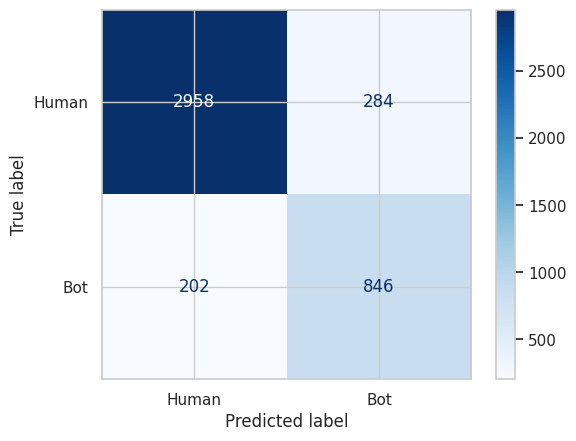

In [ ]:
# confusion metrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot']).plot(cmap='Blues')

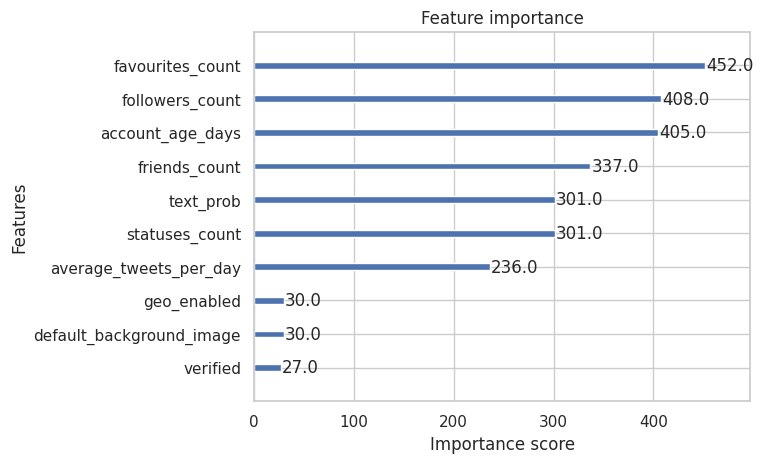

In [ ]:
plot_importance(xgb, max_num_features=10)
plt.show()